In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/store_daily_sales.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Store", "Date"])

store_1 = df[df["Store"] == 1].copy()

store_1 = store_1.sort_values("Date")

store_1.head()

,Store,Date,Sales
0,1,2013-01-02,5530
1,1,2013-01-03,4327
2,1,2013-01-04,4486
3,1,2013-01-05,4997
4,1,2013-01-07,7176


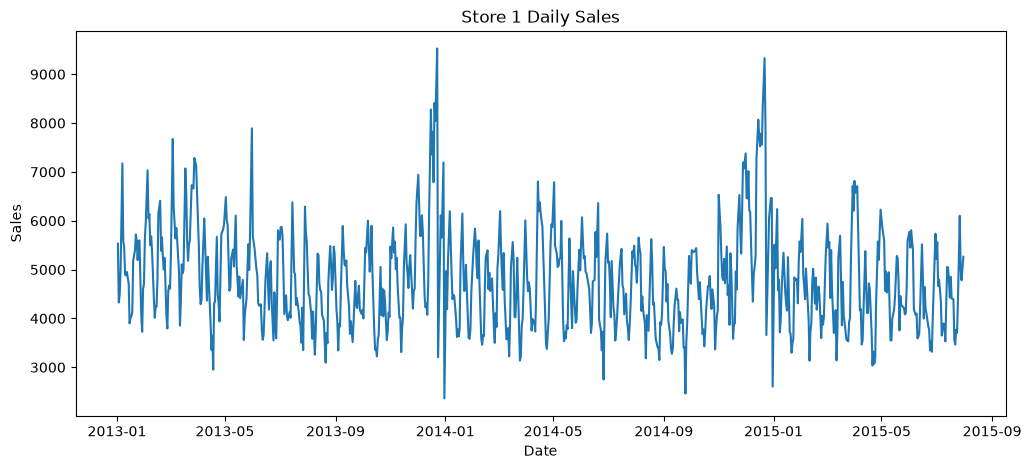

In [2]:
plt.figure(figsize=(12, 5))

plt.plot(store_1["Date"], store_1["Sales"])

plt.title("Store 1 Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(store_1["Sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.3996233378240035
p-value: 3.393379524432047e-06


C:\Users\Shrey\AppData\Local\Temp\ipykernel_5820\1873382487.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(store_1["Sales"])


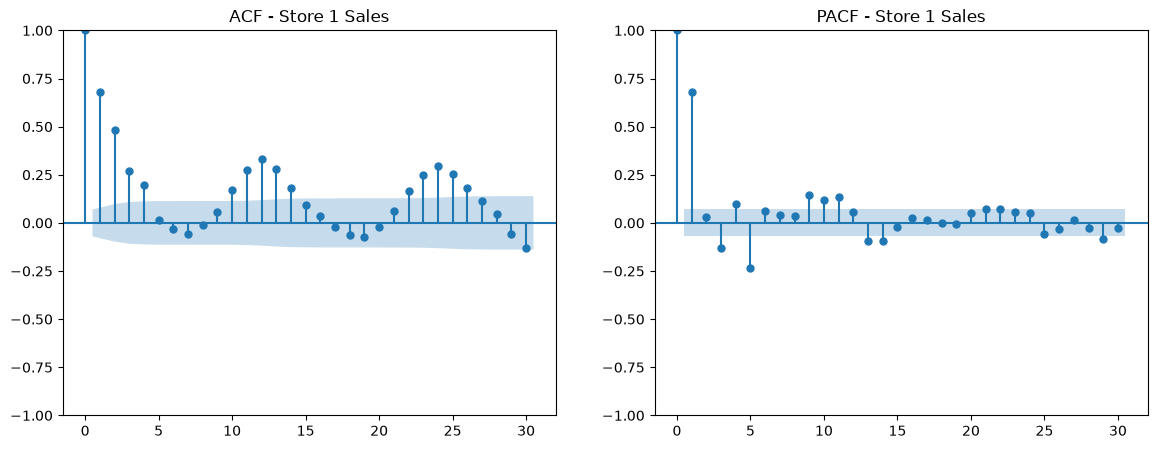

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(store_1["Sales"], ax=axes[0], lags=30)
axes[0].set_title("ACF - Store 1 Sales")

plot_pacf(store_1["Sales"], ax=axes[1], lags=30)
axes[1].set_title("PACF - Store 1 Sales")

plt.show()

In [6]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    store_1["Sales"],
    order=(1, 0, 1)
)

arima_model = model.fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  781
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6267.113
Date:                Wed, 07 Oct 2026   AIC                          12542.226
Time:                        01:51:13   BIC                          12560.868
Sample:                             0   HQIC                         12549.395
                                - 781                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4759.0960     94.631     50.291      0.000    4573.623    4944.569
ar.L1          0.6979      0.026     26.533      0.000       0.646       0.749
ma.L1         -0.0294      0.034     -0.877      0.3

In [7]:
# Train and test split

train_data = store_1.iloc[:-30]
test_data = store_1.iloc[-30:]

print("Training:", len(train_data))
print("Testing:", len(test_data))

Training: 751
Testing: 30


In [8]:
from statsmodels.tsa.arima.model import ARIMA

arima_train_model = ARIMA(
    train_data["Sales"],
    order=(1, 0, 1)
).fit()

print(arima_train_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  751
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6032.212
Date:                Wed, 07 Oct 2026   AIC                          12072.423
Time:                        01:52:41   BIC                          12090.909
Sample:                             0   HQIC                         12079.546
                                - 751                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4767.8256     98.526     48.392      0.000    4574.719    4960.932
ar.L1          0.7026      0.027     26.168      0.000       0.650       0.755
ma.L1         -0.0346      0.034     -1.008      0.3

In [9]:
forecast = arima_train_model.forecast(steps=30)

forecast.head(10)

751    3768.982585
752    4066.064384
753    4274.786354
754    4421.428997
755    4524.456317
756    4596.840640
757    4647.695988
758    4683.425638
759    4708.528363
760    4726.164887
Name: predicted_mean, dtype: float64

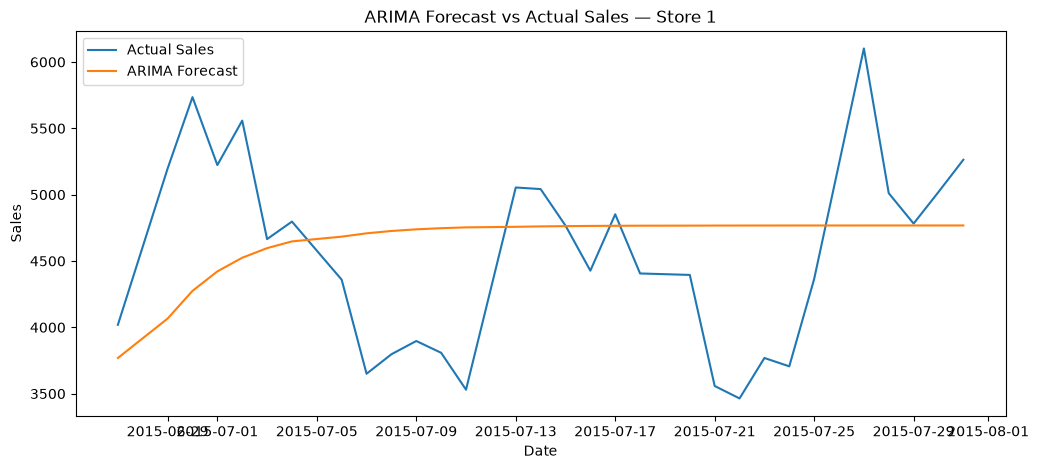

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_data["Date"],
    test_data["Sales"],
    label="Actual Sales"
)

plt.plot(
    test_data["Date"],
    forecast.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Sales — Store 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(
    test_data["Sales"],
    forecast
)

print("ARIMA MAE:", arima_mae)

ARIMA MAE: 642.0846466893994


In [12]:
residuals = test_data["Sales"] - forecast.values

print("Mean Residual:", residuals.mean())
print("Residual Std:", residuals.std())

Mean Residual: -115.31865907859334
Residual Std: 790.8925556064255


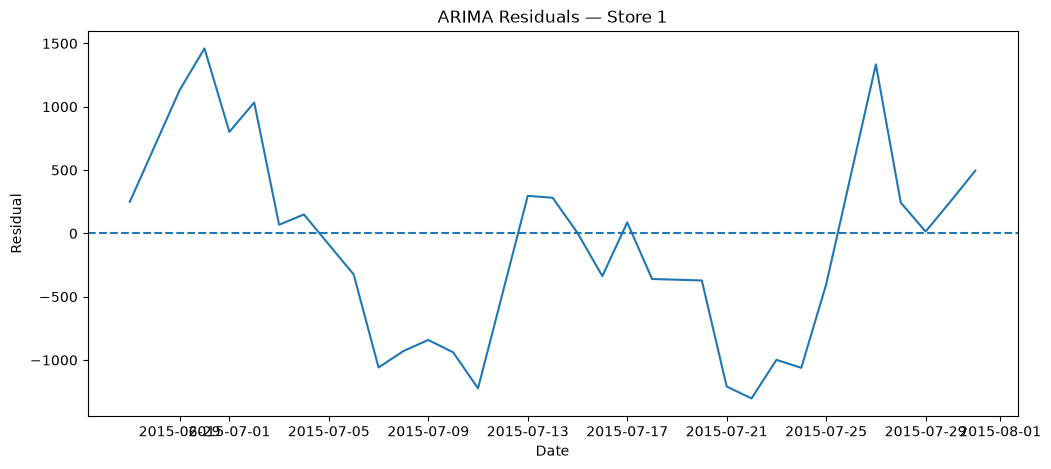

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(test_data["Date"], residuals)

plt.axhline(y=0, linestyle="--")

plt.title("ARIMA Residuals — Store 1")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[7],
    return_df=True
)

print(ljung_box)

     lb_stat  lb_pvalue
7  34.545038   0.000014
